# Project Name

Mental Health in Tech Workplace: Exploratory Data Analysis

# Project Summary

This project analyzes the Mental Health in Tech Survey dataset to understand employee mental health, treatment patterns, and workplace support in the technology sector.

# Problem Statement

Mental health can affect employee well-being and work performance. This project analyzes mental health awareness, treatment, and workplace support among employees in the technology sector.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
url = "https://raw.githubusercontent.com/techtenant/OSMI-Mental-Health-in-Tech-Survey/master/survey.csv"

df = pd.read_csv(url)
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [7]:
print("Rows and Columns:", df.shape)
df.info()

Rows and Columns: (1259, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 no

In [8]:
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


In [9]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df = df[(df["Age"] >= 15) & (df["Age"] <= 80)]

df["Gender"] = df["Gender"].astype(str).str.lower().str.strip()

def clean_gender(x):
    if x in ["male", "m", "man"]:
        return "Male"
    elif x in ["female", "f", "woman"]:
        return "Female"
    else:
        return "Other"

df["Gender"] = df["Gender"].apply(clean_gender)

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")

print("Cleaned data shape:", df.shape)
df.head()

Cleaned data shape: (1251, 27)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,Unknown,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,Unknown
1,2014-08-27 11:29:37,44,Male,United States,IN,Unknown,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,Unknown
2,2014-08-27 11:29:44,32,Male,Canada,Unknown,Unknown,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,Unknown
3,2014-08-27 11:29:46,31,Male,United Kingdom,Unknown,Unknown,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,Unknown
4,2014-08-27 11:30:22,31,Male,United States,TX,Unknown,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,Unknown


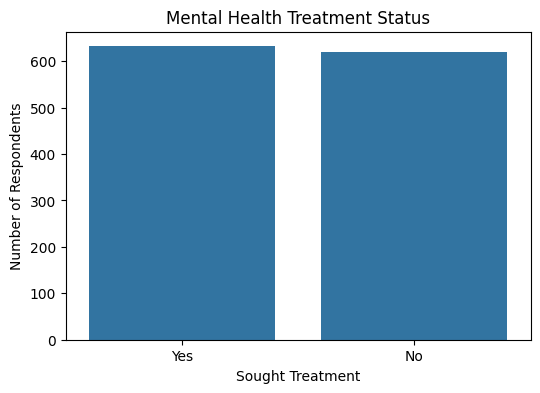

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="treatment")
plt.title("Mental Health Treatment Status")
plt.xlabel("Sought Treatment")
plt.ylabel("Number of Respondents")
plt.show()

## Insight 1

This chart shows the number of respondents who have sought treatment for a mental health condition.

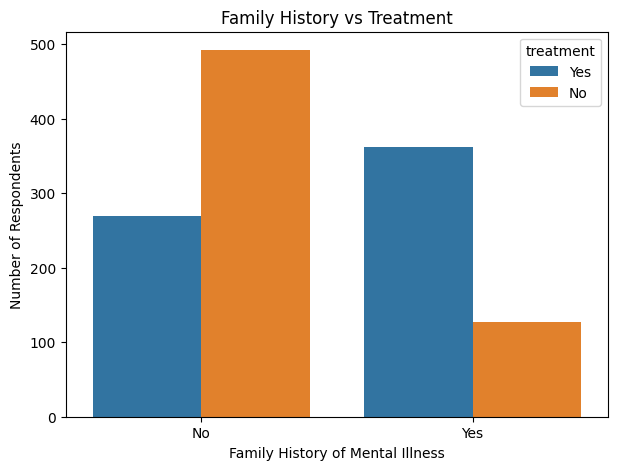

In [11]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="family_history", hue="treatment")
plt.title("Family History vs Treatment")
plt.xlabel("Family History of Mental Illness")
plt.ylabel("Number of Respondents")
plt.show()

## Insight 2

This chart compares treatment status with family history of mental illness.

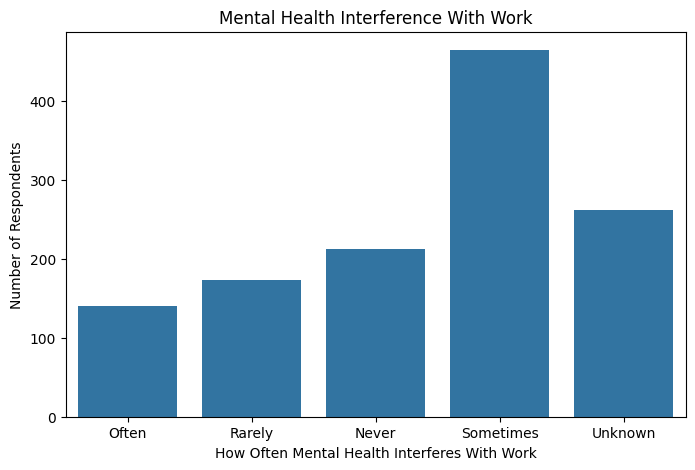

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="work_interfere")
plt.title("Mental Health Interference With Work")
plt.xlabel("How Often Mental Health Interferes With Work")
plt.ylabel("Number of Respondents")
plt.show()

## Insight 3

This chart shows how often respondents feel that mental health conditions interfere with their work.

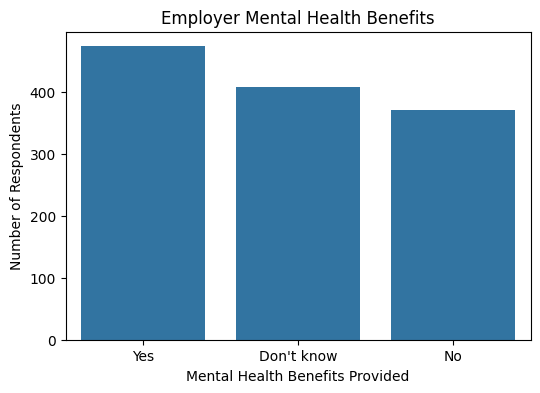

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="benefits")
plt.title("Employer Mental Health Benefits")
plt.xlabel("Mental Health Benefits Provided")
plt.ylabel("Number of Respondents")
plt.show()

## Insight 4

This chart shows whether employers provide mental health benefits to employees.

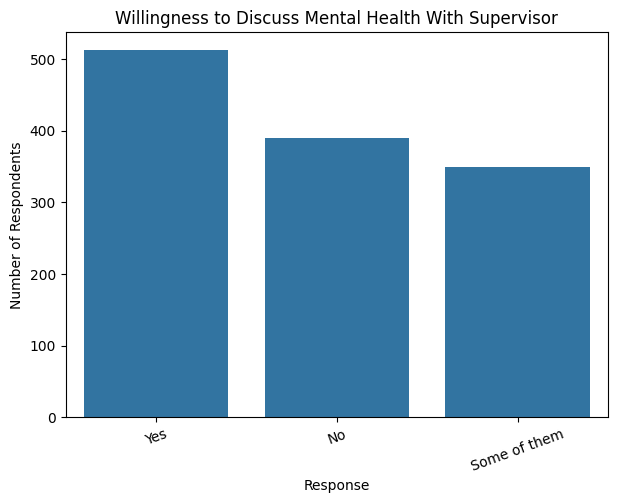

In [14]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="supervisor")
plt.title("Willingness to Discuss Mental Health With Supervisor")
plt.xlabel("Response")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=20)
plt.show()

## Insight 5

This chart shows whether employees are willing to discuss mental health issues with their direct supervisor.

# Conclusion

This analysis shows that mental health is an important issue in the technology workplace. Some employees have sought treatment, and many respondents reported that mental health can affect their work.

The charts also show the importance of family history, employer mental health benefits, and a supportive environment where employees can discuss concerns with supervisors. Companies should provide clear mental health support, benefits, and awareness programs.

This survey was conducted in 2014, so the results may not represent every current technology workplace.

# GitHub Link

https://github.com/daya91/mental-health-tech-eda